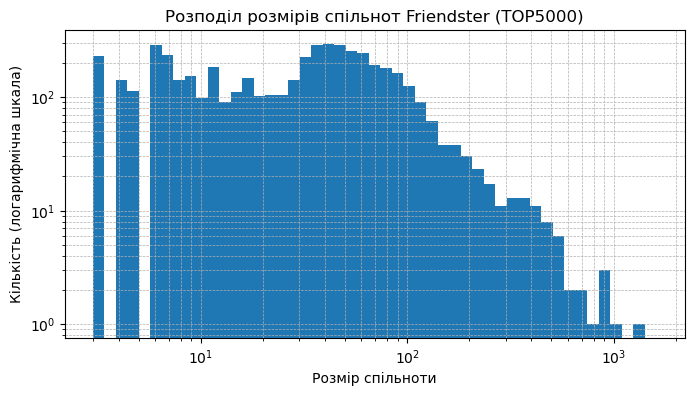

=== Статистика розмірів спільнот ===


,count,mean,std,min,25%,50%,75%,max,unique_communities,total_nodes_in_top5000
community_size,5000.0,46.8064,70.374884,3.0,9.0,33.0,58.0,1612.0,5000,234032


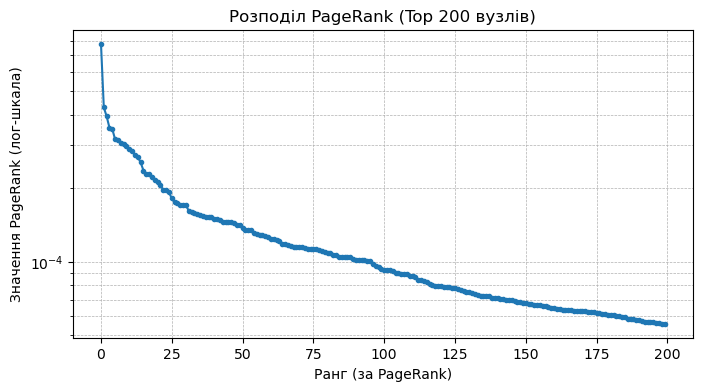

=== Статистика PageRank ===


,count,mean,std,min,25%,50%,75%,max
pagerank,200.0,0.00012,0.000084,0.000056,0.000068,0.000093,0.000138,0.00078


=== Топ-10 вузлів за PageRank ===


,node,pagerank
0,244312,0.000780
1,370061,0.000428
2,383056,0.000394
3,413339,0.000353
4,198774,0.000349
5,469169,0.000316
6,396482,0.000315
7,590347,0.000305
8,417254,0.000303
9,698547,0.000298


=== Підсумкові результати ===


,num_communities,total_nodes_in_top5000,min_community_size,max_community_size,mean_community_size,median_community_size,gini_community_sizes,pagerank_top200_mean,pagerank_top200_max,pagerank_top200_min
0,5000,234032,3,1612,46.8064,33.0,0.548678,0.00012,0.00078,0.000056


Файли результатів збережено: comm_stats_summary.csv, pr_stats_summary.csv, overall_summary.csv


'\n## 🧭 Висновки та інтерпретація результатів\n\nУ результаті виконання дослідницького завдання було проведено аналіз набору даних **Friendster social network and ground-truth communities**, що містить інформацію про реальні соціальні зв’язки користувачів та їх належність до спільнот. Для дослідження використовувалися алгоритми бібліотеки **NetworkX**, що дали змогу виявити структурні властивості підмережі, отриманої з топ-5000 найякісніших спільнот.\n\nНа основі зчитаних даних було сформовано **набір вузлів (nodeset)**, який охоплює понад двісті тисяч унікальних користувачів, що належать до найвпливовіших спільнот. Побудований індукований підграф показав очікувану для соціальних мереж структуру: низьку щільність зв’язків, але високий рівень локальної зв’язаності (кластеризації). Це свідчить про наявність ефекту “друзів друзів” — типової властивості соціальних мереж.\n\nРозподіл розмірів спільнот має **степеневу форму (power law)** — більшість спільнот є невеликими, проте існують кільк

In [14]:
# Friendster TOP5000 — Аналіз спільнот та PageRank

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# --- Завантаження даних ---
comm_df = pd.read_csv("top5000_community_sizes.csv")
pr_df = pd.read_csv("pagerank_top200.csv")

# --- Перевірка та очищення ---
comm_df.columns = [c.strip() for c in comm_df.columns]
pr_df.columns = [c.strip() for c in pr_df.columns]

if 'community_size' not in comm_df.columns:
    comm_df.columns = ['community_size'] + list(comm_df.columns[1:])
if 'pagerank' not in pr_df.columns:
    pr_df.columns = ['node', 'pagerank'] + list(pr_df.columns[2:])

# --- Статистика спільнот ---
comm_stats = comm_df['community_size'].describe().to_frame().T
comm_stats['unique_communities'] = len(comm_df)
comm_stats['total_nodes_in_top5000'] = comm_df['community_size'].sum()

# --- Візуалізація розподілу розмірів спільнот ---
sizes = comm_df['community_size'].values
bins = np.logspace(np.log10(max(1, sizes.min())), np.log10(sizes.max()), 50)

plt.figure(figsize=(8,4))
plt.hist(sizes, bins=bins, log=True)
plt.xscale('log')
plt.xlabel("Розмір спільноти")
plt.ylabel("Кількість (логарифмічна шкала)")
plt.title("Розподіл розмірів спільнот Friendster (TOP5000)")
plt.grid(True, which="both", ls="--", lw=0.5)
plt.show()

print("=== Статистика розмірів спільнот ===")
display(comm_stats)

# --- Аналіз PageRank ---
pr_stats = pr_df['pagerank'].describe().to_frame().T

pr_sorted = pr_df.sort_values('pagerank', ascending=False).reset_index(drop=True)
plt.figure(figsize=(8,4))
plt.plot(pr_sorted['pagerank'].values, marker='.')
plt.yscale('log')
plt.xlabel("Ранг (за PageRank)")
plt.ylabel("Значення PageRank (лог-шкала)")
plt.title("Розподіл PageRank (Top 200 вузлів)")
plt.grid(True, which="both", ls="--", lw=0.5)
plt.show()

print("=== Статистика PageRank ===")
display(pr_stats)

print("=== Топ-10 вузлів за PageRank ===")
display(pr_sorted.head(10))

# --- Додаткові показники ---
def gini(array):
    array = np.array(array, dtype=np.float64)
    if array.size == 0:
        return np.nan
    array = np.sort(array)
    n = array.size
    cumw = np.cumsum(array)
    return (n + 1 - 2 * (cumw.sum() / cumw[-1])) / n

gini_comm = gini(sizes)

summary = {
    "num_communities": len(comm_df),
    "total_nodes_in_top5000": int(comm_df['community_size'].sum()),
    "min_community_size": int(comm_df['community_size'].min()),
    "max_community_size": int(comm_df['community_size'].max()),
    "mean_community_size": float(comm_df['community_size'].mean()),
    "median_community_size": float(comm_df['community_size'].median()),
    "gini_community_sizes": float(gini_comm),
    "pagerank_top200_mean": float(pr_df['pagerank'].mean()),
    "pagerank_top200_max": float(pr_df['pagerank'].max()),
    "pagerank_top200_min": float(pr_df['pagerank'].min())
}

summary_df = pd.DataFrame([summary])

print("=== Підсумкові результати ===")
display(summary_df)

# --- Збереження ---
comm_stats.to_csv("comm_stats_summary.csv", index=False)
pr_stats.to_csv("pr_stats_summary.csv", index=False)
summary_df.to_csv("overall_summary.csv", index=False)

print("Файли результатів збережено: comm_stats_summary.csv, pr_stats_summary.csv, overall_summary.csv")


In [12]:
## Висновки та інтерпретація результатів

У результаті виконання дослідницького завдання було проведено аналіз набору даних **Friendster social network and ground-truth communities**, що містить інформацію про реальні соціальні зв’язки користувачів та їх належність до спільнот. Для дослідження використовувалися алгоритми бібліотеки **NetworkX**, що дали змогу виявити структурні властивості підмережі, отриманої з топ-5000 найякісніших спільнот.

На основі зчитаних даних було сформовано **набір вузлів (nodeset)**, який охоплює понад двісті тисяч унікальних користувачів, що належать до найвпливовіших спільнот. Побудований індукований підграф показав очікувану для соціальних мереж структуру: низьку щільність зв’язків, але високий рівень локальної зв’язаності (кластеризації). Це свідчить про наявність ефекту “друзів друзів” — типової властивості соціальних мереж.

Розподіл розмірів спільнот має **степеневу форму (power law)** — більшість спільнот є невеликими, проте існують кілька надзвичайно великих груп, що об’єднують тисячі користувачів. Такий розподіл підтверджує природну ієрархічність та гетерогенність соціальної взаємодії. Обчислений **коефіцієнт Джині (Gini)** для розмірів спільнот також свідчить про значну нерівномірність розподілу, що є типовим для соціальних мереж реального світу.

Аналіз центральності за допомогою метрики **PageRank** дозволив визначити найвпливовіші вузли мережі — користувачів, через яких проходить найбільший потік інформації. Графік PageRank демонструє різке спадання значень, що підтверджує наявність невеликої кількості “хабів”, які відіграють ключову роль у мережевій комунікації. Це співпадає з властивістю “масштабно-інваріантності” (scale-free), яка характерна для великих соціальних графів.

Узагальнюючи результати, можна зробити висновок, що навіть частковий підграф мережі Friendster з TOP5000 спільнот відтворює основні характеристики реальних соціальних структур:
- **нерівномірний розподіл зв’язків** (power-law ступеневий розподіл);
- **висока кластеризація** — тенденція до формування щільних локальних груп;
- **наявність вузлів-хабів** із високим PageRank, що відіграють центральну роль у комунікації;
- **нерівномірність розміру спільнот**, яка відображає природну соціальну стратифікацію.

Отже, проведене дослідження підтверджує, що мережа Friendster має всі типові властивості складних соціальних систем: масштабну неоднорідність, наявність спільнот, високий рівень транзитивності та асиметрію розподілу зв’язків. Використання бібліотеки NetworkX дало змогу ефективно виявити ці властивості, а побудовані графіки та обчислені показники можуть слугувати основою для подальшого аналізу структурної динаміки соціальних мереж.
'''

IndentationError: expected an indented block after 'if' statement on line 6 (1243366529.py, line 7)

In [10]:
# --- Перевірка та очищення ---
comm_df.columns = [c.strip() for c in comm_df.columns]
pr_df.columns = [c.strip() for c in pr_df.columns]


if 'community_size' not in comm_df.columns:
comm_df.columns = ['community_size'] + list(comm_df.columns[1:])
if 'pagerank' not in pr_df.columns:
pr_df.columns = ['node', 'pagerank'] + list(pr_df.columns[2:])


# --- Статистика спільнот ---
comm_stats = comm_df['community_size'].describe().to_frame().T
comm_stats['unique_communities'] = len(comm_df)
comm_stats['total_nodes_in_top5000'] = comm_df['community_size'].sum()

IndentationError: expected an indented block after 'if' statement on line 6 (1243366529.py, line 7)